In [27]:
### Importing required library 
import numpy as np 
from rdkit.Chem import AllChem
import pickle
import pandas as pd
from rdkit import Chem
import xgboost
import base64
import pickle
import numpy as np
import pandas as pd
from rdkit import Chem,DataStructs
from rdkit.Chem import MolFromSmiles, Descriptors
from rdkit.ML.Descriptors import MoleculeDescriptors
from rdkit.Chem import Descriptors
from rdkit.Chem import Lipinski
from rdkit.Chem import Crippen
import base64
import shap
from xgboost import XGBRegressor
import xgboost as xgb
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem import rdMolDescriptors
import requests
from bs4 import BeautifulSoup
import deepchem as dc
from sklearn.preprocessing import StandardScaler

In [28]:
import pandas as pd 
df_set1 = pd.read_excel('data/JCIM_PredictionJCIM_test.xlsx', sheet_name="SET1")
df_set2 = pd.read_excel('data/JCIM_PredictionJCIM_test.xlsx', sheet_name="SET2")

In [29]:
print(df_set1.shape)
print(df_set2.shape)

(100, 4)
(32, 4)


In [30]:

train_set =pd.read_csv('data/final_data/unique_train4_new26.csv')

In [31]:
from rdkit.Chem import MolFromSmiles as smi2mol
from rdkit.Chem import MolToSmiles as mol2smi

## Function to create canonical smiles 
def canon(smi):
    try:
        mol=smi2mol(smi, sanitize=True)
        smi_canon=mol2smi(mol, isomericSmiles=False, canonical=True)
        return(smi_canon)
    except:
        print("ERROR")
        return(smi)

In [32]:
df_set1['smiles_canon'] = [canon(smi) for smi in df_set1.SMILES]
df_set2['smiles_canon'] = [canon(smi) for smi in df_set2.SMILES]

In [33]:
### Finding the match between train and test data 
Match_rows_set1 = pd.merge(df_set1, train_set, on=['smiles_canon'], how='inner')
#mergedStuff.head()
print(len(Match_rows_set1))

37


In [34]:
### Finding the matching smiles in the train dataset..and removing it 
cond = train_set['smiles_canon'].isin(Match_rows_set1['smiles_canon'])

#### Dropping the smiles which is same and making dataframe with uniques smiles and no smiles same in ttrain  dataset 
train_set.drop(train_set[cond].index, inplace = True)

In [35]:
train_set.shape

(17900, 7)

In [36]:
### Match with remaining train set 
Match_rows_set2 = pd.merge(df_set2, train_set, on=['smiles_canon'], how='inner')
#mergedStuff.head()
print(len(Match_rows_set2))

16


In [37]:
### Finding the matching smiles in the train dataset..and removing it 
cond = train_set['smiles_canon'].isin(Match_rows_set2['smiles_canon'])

#### Dropping the smiles which is same and making dataframe with uniques smiles and no smiles same in ttrain  dataset 
train_set.drop(train_set[cond].index, inplace = True)

In [38]:
train_set.shape

(17884, 7)

In [25]:
### Now there is no data in train set which match with df_set1 or df_set2 

In [39]:
### After removing the data match with train data 
print(df_set1.shape)
print(df_set2.shape) 

(100, 5)
(32, 5)


In [40]:
df_set1

,Sr No,COMPOUND_Name,SMILES,LogS,smiles_canon
0,1,Acetazolamide,CC(NC1=NN=C(S1)[S](N)(=O)=O)=O,-2.38,CC(=O)Nc1nnc(S(N)(=O)=O)s1
1,2,Acetylsalicylic_Acid,C(C)(=O)OC1=CC=CC=C1C(=O)O,-1.67,CC(=O)Oc1ccccc1C(=O)O
2,3,Alclofenac,C=CCOc1ccc(cc1Cl)CC(=O)O,-4.40,C=CCOc1ccc(CC(=O)O)cc1Cl
3,4,Ambroxol,O[C@@H]2CC[C@@H](NCc1cc(Br)cc(Br)c1N)CC2,-3.87,Nc1c(Br)cc(Br)cc1CNC1CCC(O)CC1
4,5,Aripiprazole,O=C1Nc2c(ccc(OCCCCN3CCN(c4c(Cl)c(Cl)ccc4)CC3)c...,-6.64,O=C1CCc2ccc(OCCCCN3CCN(c4cccc(Cl)c4Cl)CC3)cc2N1
...,...,...,...,...,...
95,96,Thiacetazone,C1=C(C=CC(=C1)NC(=O)C)/C=N/NC(=S)N,-3.50,CC(=O)Nc1ccc(C=NNC(N)=S)cc1
96,97,Triamcinolone,[C@]23([C@H]([C@H]1[C@]([C@](C(CO)=O)(O)[C@@H]...,-3.52,CC12C=CC(=O)C=C1CCC1C3CC(O)C(O)(C(=O)CO)C3(C)C...
97,98,Triamterene,C3=C(C1=C(N=C2C(=N1)C(=NC(=N2)N)N)N)C=CC=C3,-4.11,Nc1nc(N)c2nc(-c3ccccc3)c(N)nc2n1
98,99,Warfarin,C3=C(C(C1=C(OC2=C(C1=O)C=CC=C2)O)CC(=O)C)C=CC=C3,-4.78,CC(=O)CC(c1ccccc1)c1c(O)oc2ccccc2c1=O


In [41]:
#### All the function to create the descriptors 
import pandas as pd
def calculate_aromatic_proportion(smiles):
    # Parse SMILES string and generate molecular representation
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None  # Invalid SMILES
    
    # Identify aromatic atoms
    aromatic_atoms = [atom.GetAtomicNum() for atom in mol.GetAtoms() if atom.GetIsAromatic()]
    
    # Calculate aromatic proportion
    total_atoms = mol.GetNumAtoms()
    aromatic_proportion = len(aromatic_atoms) / total_atoms
    
    return aromatic_proportion
####  function for handling single smiles 
def calculate_rdkit_features(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if not mol:
        raise ValueError("Invalid SMILES string.")
    
    # List of RDKit descriptors
    descriptor_names = [desc[0] for desc in Descriptors._descList]
    descriptor_funcs = [desc[1] for desc in Descriptors._descList]
    
    # Compute descriptors
    features = [func(mol) for func in descriptor_funcs]
    
    # Create DataFrame
    df = pd.DataFrame([features], columns=descriptor_names)
    return df
#### Function for list of the smiles 
def calculate_rdkit_features1(smiles_list):
    """
    Calculate RDKit descriptors for a list of SMILES strings.

    Parameters:
        smiles_list (list of str): List of SMILES strings.

    Returns:
        pd.DataFrame: A DataFrame where each row corresponds to a SMILES string
                      and each column corresponds to a descriptor.
    """
    # List of RDKit descriptors
    descriptor_names = [desc[0] for desc in Descriptors._descList]
    descriptor_funcs = [desc[1] for desc in Descriptors._descList]

    data = []
    invalid_smiles = []

    for i, smiles in enumerate(smiles_list):
        mol = Chem.MolFromSmiles(smiles)
        if not mol:
            invalid_smiles.append((i, smiles))
            continue
        
        # Compute descriptors
        features = [func(mol) for func in descriptor_funcs]
        data.append(features)

    # Create DataFrame
    df = pd.DataFrame(data, columns=descriptor_names, index=[i for i, smiles in enumerate(smiles_list) if smiles not in dict(invalid_smiles)])

    # Log invalid SMILES strings
    if invalid_smiles:
        print(f"Invalid SMILES found at indices: {[idx for idx, sm in invalid_smiles]}\nInvalid SMILES: {[sm for idx, sm in invalid_smiles]}")

    return df
### function for single smiles and list of the smiles 
def fingerprint1(smiles, r, n): 
    # Check if input is a single SMILES string or a list
    if isinstance(smiles, str):
        smiles = [smiles]  # Convert single SMILES string to a list

    # Convert SMILES strings to RDKit molecules
    mols = [Chem.MolFromSmiles(SMILES_string) for SMILES_string in smiles]

    # Compute fingerprints
    fingerprints_array = []
    for m in mols:
        bi = {}
        fingerprint = rdMolDescriptors.GetMorganFingerprintAsBitVect(m, radius=r, nBits=n, bitInfo=bi)
        array = np.zeros((1,), dtype=int)
        DataStructs.ConvertToNumpyArray(fingerprint, array)
        fingerprints_array.append(array)

    # Convert to a DataFrame with bits as columns
    fingerprints_df = pd.DataFrame(fingerprints_array)

    # Return the DataFrame for a single SMILES
    return fingerprints_df
def get_charges(smiles):
    if '+' in smiles:
        return 1
    elif '-' in smiles:
        return -1
    else:
        return 0

def get_many_double_bonds(smiles):
    mol = Chem.MolFromSmiles(smiles)
    double_bond_count = sum(1 for bond in mol.GetBonds() if bond.GetBondType() == Chem.rdchem.BondType.DOUBLE)
    return 1 if double_bond_count > 4 else 0

def get_atom_degrees(smiles):
    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol)
    bonds = mol.GetBonds()
    sum_degree_vector = np.zeros(7)
    for bond in bonds:
        atom1 = bond.GetBeginAtom()
        atom2 = bond.GetEndAtom()
        atom_degree_vector = np.array([1 if atom1.GetDegree() == d else 0 for d in range(7)])
        sum_degree_vector += atom_degree_vector
        atom_degree_vector = np.array([1 if atom2.GetDegree() == d else 0 for d in range(7)])
        sum_degree_vector += atom_degree_vector
    return sum_degree_vector.astype(int)

def get_atom_valences(smiles):
    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol)
    bonds = mol.GetBonds()
    sum_valence_vector = np.zeros(7)
    for bond in bonds:
        atom1 = bond.GetBeginAtom()
        atom2 = bond.GetEndAtom()
        atom_valence_vector = np.array([1 if atom1.GetTotalValence() == v else 0 for v in range(7)])
        sum_valence_vector += atom_valence_vector
        atom_valence_vector = np.array([1 if atom2.GetTotalValence() == v else 0 for v in range(7)])
        sum_valence_vector += atom_valence_vector
    return sum_valence_vector.astype(int)

def get_atom_hybridization(smiles):
    hybridizations = [
        Chem.rdchem.HybridizationType.S,
        Chem.rdchem.HybridizationType.SP, 
        Chem.rdchem.HybridizationType.SP2, 
        Chem.rdchem.HybridizationType.SP3, 
        Chem.rdchem.HybridizationType.SP3D, 
        Chem.rdchem.HybridizationType.SP3D2, 
        Chem.rdchem.HybridizationType.UNSPECIFIED]
    
    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol)
    bonds = mol.GetBonds()
    sum_hybrid_vector = np.zeros(7)
    for bond in bonds:
        atom1 = bond.GetBeginAtom()
        atom2 = bond.GetEndAtom()
        atom_hybrid_vector = np.array([1 if atom1.GetHybridization() == h else 0 for h in hybridizations])
        sum_hybrid_vector += atom_hybrid_vector
        atom_hybrid_vector = np.array([1 if atom2.GetHybridization() == h else 0 for h in hybridizations])
        sum_hybrid_vector += atom_hybrid_vector
    return sum_hybrid_vector.astype(int)

def get_aromatic_atoms(smiles):
    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol)
    bonds = mol.GetBonds()
    sum_aromatic_vector = np.zeros(1)
    for bond in bonds:
        atom1 = bond.GetBeginAtom()
        atom2 = bond.GetEndAtom()
        atom_aromatic_vector = np.array([1 if atom1.GetIsAromatic() else 0])
        sum_aromatic_vector += atom_aromatic_vector
        atom_aromatic_vector = np.array([1 if atom2.GetIsAromatic() else 0])
        sum_aromatic_vector += atom_aromatic_vector
    return sum_aromatic_vector.astype(int)[0]

def get_bond_types(smiles):
    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol)
    bonds = mol.GetBonds()
    sum_bond_type_vector = np.zeros(5)
    for bond in bonds:
        bond_type = bond.GetBondType().name
        bond_type_vector = np.array([1 if t == bond_type else 0 for t in ['SINGLE', 'DOUBLE', 'TRIPLE', 'AROMATIC', 'ZERO']])
        sum_bond_type_vector += bond_type_vector
    return sum_bond_type_vector.astype(int)

def is_conjugated(smiles):
    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol)
    bonds = mol.GetBonds()
    sum_conjugated = np.zeros(1)
    for bond in bonds:
        is_conjugated = 1 if bond.GetIsConjugated() else 0
        conjugation_vector = np.array([is_conjugated])
        sum_conjugated += conjugation_vector
    return sum_conjugated.astype(int)[0]

def get_bonds_in_ring(smiles):
    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol)
    return len(Chem.GetSymmSSSR(mol))

def get_bond_chirality(smiles):
    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol)
    bonds = mol.GetBonds()
    sum_chirality = np.zeros(4)
    for bond in bonds:
        chirality = bond.GetStereo()
        chirality_vector = np.array([1 if chirality == c else 0 for c in [Chem.rdchem.BondStereo.STEREONONE,
                                                                          Chem.rdchem.BondStereo.STEREOANY,
                                                                          Chem.rdchem.BondStereo.STEREOZ,
                                                                          Chem.rdchem.BondStereo.STEREOE]])
        sum_chirality += chirality_vector
    return sum_chirality.astype(int)

def get_n_atoms(smiles):
    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol)
    return mol.GetNumAtoms()

def get_n_bonds(smiles):
    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol)
    return mol.GetNumBonds()

def get_n_rings(smiles):
    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol)
    return len(Chem.GetSymmSSSR(mol))
### Funntion for creating 38 features for single smiles 
def generate_features_single38(smiles):
    columns = [
        'charge', 'many_double_bonds', 'atoms_degree_0', 'atoms_degree_1',
        'atoms_degree_2', 'atoms_degree_3', 'atoms_degree_4', 'atoms_degree_5',
        'atoms_degree_6', 'atoms_valence_0', 'atoms_valence_1', 'atoms_valence_2',
        'atoms_valence_3', 'atoms_valence_4', 'atoms_valence_5', 'atoms_valence_6',
        'atom_hybridization_S', 'atom_hybridization_SP', 'atom_hybridization_SP2',
        'atom_hybridization_SP3', 'atom_hybridization_SP3D', 'atom_hybridization_SP3D2',
        'atom_hybridization_UNSPECIFIED', 'aromatic_atoms', 'single_bonds', 'double_bonds',
        'triple_bonds', 'aromatic_bonds', 'zero_bonds', 'conjugated_bonds', 'bonds_in_ring',
        'chirality_none', 'chirality_any', 'chirality_z', 'chirality_e', 'n_atoms',
        'n_bonds', 'n_rings'
    ]

    # Calculate features for the single SMILES string
    charge = get_charges(smiles)
    many_double_bonds = get_many_double_bonds(smiles)
    atom_degrees = get_atom_degrees(smiles).tolist()
    atom_valences = get_atom_valences(smiles).tolist()
    atom_hybridizations = get_atom_hybridization(smiles).tolist()
    aromatic_atoms = get_aromatic_atoms(smiles)
    bond_types = get_bond_types(smiles).tolist()
    conjugated_bonds = is_conjugated(smiles)
    bonds_in_ring = get_bonds_in_ring(smiles)
    bond_chirality = get_bond_chirality(smiles).tolist()
    n_atoms = get_n_atoms(smiles)
    n_bonds = get_n_bonds(smiles)
    n_rings = get_n_rings(smiles)

    # Combine all features into a single row
    feature_row = [
        charge, many_double_bonds, atom_degrees[0], atom_degrees[1],
        atom_degrees[2], atom_degrees[3], atom_degrees[4], atom_degrees[5],
        atom_degrees[6], atom_valences[0], atom_valences[1], atom_valences[2],
        atom_valences[3], atom_valences[4], atom_valences[5], atom_valences[6],
        atom_hybridizations[0], atom_hybridizations[1], atom_hybridizations[2],
        atom_hybridizations[3], atom_hybridizations[4], atom_hybridizations[5],
        atom_hybridizations[6], aromatic_atoms, bond_types[0], bond_types[1],
        bond_types[2], bond_types[3], bond_types[4], conjugated_bonds,
        bonds_in_ring, bond_chirality[0], bond_chirality[1], bond_chirality[2],
        bond_chirality[3], n_atoms, n_bonds, n_rings
    ]

    # Convert the feature row into a DataFrame
    return pd.DataFrame([feature_row], columns=columns)
#### function for creating the 38 features for list of the smiles 
def generate_features38(smiles_list):
    columns = [
        'charge', 'many_double_bonds', 'atoms_degree_0', 'atoms_degree_1',
        'atoms_degree_2', 'atoms_degree_3', 'atoms_degree_4', 'atoms_degree_5',
        'atoms_degree_6', 'atoms_valence_0', 'atoms_valence_1', 'atoms_valence_2',
        'atoms_valence_3', 'atoms_valence_4', 'atoms_valence_5', 'atoms_valence_6',
        'atom_hybridization_S', 'atom_hybridization_SP', 'atom_hybridization_SP2',
        'atom_hybridization_SP3', 'atom_hybridization_SP3D', 'atom_hybridization_SP3D2',
        'atom_hybridization_UNSPECIFIED', 'aromatic_atoms', 'single_bonds', 'double_bonds',
        'triple_bonds', 'aromatic_bonds', 'zero_bonds', 'conjugated_bonds', 'bonds_in_ring',
        'chirality_none', 'chirality_any', 'chirality_z', 'chirality_e', 'n_atoms',
        'n_bonds', 'n_rings'
    ]
    
    features = []
    for smiles in smiles_list:
        charge = get_charges(smiles)
        many_double_bonds = get_many_double_bonds(smiles)
        atom_degrees = get_atom_degrees(smiles).tolist()
        atom_valences = get_atom_valences(smiles).tolist()
        atom_hybridizations = get_atom_hybridization(smiles).tolist()
        aromatic_atoms = get_aromatic_atoms(smiles)
        bond_types = get_bond_types(smiles).tolist()
        conjugated_bonds = is_conjugated(smiles)
        bonds_in_ring = get_bonds_in_ring(smiles)
        bond_chirality = get_bond_chirality(smiles).tolist()
        n_atoms = get_n_atoms(smiles)
        n_bonds = get_n_bonds(smiles)
        n_rings = get_n_rings(smiles)

        feature_row = [
            charge, many_double_bonds, atom_degrees[0], atom_degrees[1],
            atom_degrees[2], atom_degrees[3], atom_degrees[4], atom_degrees[5],
            atom_degrees[6], atom_valences[0], atom_valences[1], atom_valences[2],
            atom_valences[3], atom_valences[4], atom_valences[5], atom_valences[6],
            atom_hybridizations[0], atom_hybridizations[1], atom_hybridizations[2],
            atom_hybridizations[3], atom_hybridizations[4], atom_hybridizations[5],
            atom_hybridizations[6], aromatic_atoms, bond_types[0], bond_types[1],
            bond_types[2], bond_types[3], bond_types[4], conjugated_bonds,
            bonds_in_ring, bond_chirality[0], bond_chirality[1], bond_chirality[2],
            bond_chirality[3], n_atoms, n_bonds, n_rings
        ]
        
        features.append(feature_row)
    
    return pd.DataFrame(features, columns=columns)

### Function for 7 groups for single smiles and list of the smiles 
def get_functional_groups1(smiles):
    from rdkit import Chem
    import pandas as pd

    functional_groups = {
        # Polar functional groups
        'Hydroxyl Group': '[OH]',
        'Carbonyl Group': 'C=O',
        'Amide Group': 'C(=O)N',
        'Carboxyl Group': 'C(=O)[OH]',
        # Non-polar functional groups
        'Alkyl': '[R]', 
        'Aromatic Rings': 'c',
        'Alkene': 'C=C'
    }
    
    # Check if input is a single SMILES string
    if isinstance(smiles, str):
        smiles = [smiles]  # Wrap it in a list for consistency
    
    results = []
    for s in smiles:
        mol = Chem.MolFromSmiles(s)
        if mol:  # Ensure valid SMILES
            fg_presence = {fg: 1 if mol.HasSubstructMatch(Chem.MolFromSmarts(smarts)) else 0 for fg, smarts in functional_groups.items()}
        else:
            fg_presence = {fg: 0 for fg in functional_groups}  # Default to 0 if SMILES is invalid
        #fg_presence['SMILES'] = s
        results.append(fg_presence)
    
    # Convert results to a DataFrame
    data = pd.DataFrame(results)
    
    return data
### for single smiles 
def calc_mol_weight(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        return Descriptors.MolWt(mol)
    return None
#### for smiles list 
def calc_mol_weight1(smiles_list):
    """
    Calculate molecular weights for a list of SMILES strings.

    Parameters:
        smiles_list (list of str): List of SMILES strings.

    Returns:
        list: Molecular weights for valid SMILES strings, or None for invalid ones.
    """
    return [
        Descriptors.MolWt(Chem.MolFromSmiles(smiles)) if Chem.MolFromSmiles(smiles) else None
        for smiles in smiles_list
    ]


In [42]:
SMILES=train_set.smiles_canon

In [43]:
### Generate the descriptors of the train data 
df125_new=calculate_rdkit_features1(SMILES)
                
df125 = df125_new.iloc[:, :125]
                 
df38=generate_features38(SMILES)
                
df128=fingerprint1(SMILES,2,128)
                
df7=get_functional_groups1(SMILES)
                
combined_df = pd.concat([df125, df128, df7, df38], axis=1)

[13:11:54] WARNING: not removing hydrogen atom without neighbors
[13:11:54] WARNING: not removing hydrogen atom without neighbors
[13:11:54] WARNING: not removing hydrogen atom without neighbors
[13:11:54] WARNING: not removing hydrogen atom without neighbors
[13:11:54] WARNING: not removing hydrogen atom without neighbors
[13:11:54] WARNING: not removing hydrogen atom without neighbors
[13:11:54] WARNING: not removing hydrogen atom without neighbors
[13:11:54] WARNING: not removing hydrogen atom without neighbors
[13:11:54] WARNING: not removing hydrogen atom without neighbors
[13:11:54] WARNING: not removing hydrogen atom without neighbors
[13:11:54] WARNING: not removing hydrogen atom without neighbors
[13:11:54] WARNING: not removing hydrogen atom without neighbors
[13:11:54] WARNING: not removing hydrogen atom without neighbors
[13:11:54] WARNING: not removing hydrogen atom without neighbors
[13:11:54] WARNING: not removing hydrogen atom without neighbors
[13:11:54] WARNING: not r

In [44]:
y_train=train_set['LogS']

In [45]:
y_set1=df_set1['LogS']
y_set2=df_set2['LogS']

In [46]:
SMILES_test1=df_set1.smiles_canon
SMILES_test2=df_set2.smiles_canon

In [47]:
### Generate the descriptors of the test data for set1  
df125_new=calculate_rdkit_features1(SMILES_test1)
                
df125 = df125_new.iloc[:, :125]
                 
df38=generate_features38(SMILES_test1)
                
df128=fingerprint1(SMILES_test1,2,128)
                
df7=get_functional_groups1(SMILES_test1)
                
df_test1 = pd.concat([df125, df128, df7, df38], axis=1)

In [48]:
### Generate the descriptors of the test data for set1  
df125_new=calculate_rdkit_features1(SMILES_test2)
                
df125 = df125_new.iloc[:, :125]
                 
df38=generate_features38(SMILES_test2)
                
df128=fingerprint1(SMILES_test2,2,128)
                
df7=get_functional_groups1(SMILES_test2)
                
df_test2 = pd.concat([df125, df128, df7, df38], axis=1)

In [50]:
import xgboost as xgb
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import make_scorer, mean_squared_error
import numpy as np


In [52]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Initialize K-Fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Metrics list
mae_scores = []
rmse_scores = []
r2_scores = []

test_predictions=[]

# Loop through each fold
for train_index, val_index in kf.split(combined_df):
    # Splitting train data into training and validation for the current fold
    X_train_fold, X_val_fold = combined_df.iloc[train_index], combined_df.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]
    

    
    # Initialize model to get trained on train dataset 
    model = xgboost_model = xgboost.XGBRegressor(learning_rate =0.01,n_estimators=2000,max_depth=8,min_child_weight=4,gamma=0,subsample=0.7,
                                           colsample_bytree=0.8,nthread=2,scale_pos_weight=1,seed=27)
    model.fit(X_train_fold, y_train_fold)
    

    
    
    
    # Test predictions for this fold
    y_test_pred = model.predict(df_test1)
    test_predictions.append(y_test_pred)
    mae = mean_absolute_error(y_set1, y_test_pred)
    rmse = np.sqrt(mean_squared_error(y_set1, y_test_pred))
    r2 = r2_score(y_set1, y_test_pred)
    
    mae_scores.append(mae)
    rmse_scores.append(rmse)
    r2_scores.append(r2)


# Calculate mean and standard deviation of metrics across all folds
mean_mae = np.mean(mae_scores)
std_mae = np.std(mae_scores)

mean_rmse = np.mean(rmse_scores)
std_rmse = np.std(rmse_scores)

mean_r2 = np.mean(r2_scores)
std_r2 = np.std(r2_scores)



# Output results
print("Mean and Standard Deviation of Metrics Across 5 Folds:")
print(f"MAE: Mean = {mean_mae:.4f}, Std = {std_mae:.4f}")
print(f"RMSE: Mean = {mean_rmse:.4f}, Std = {std_rmse:.4f}")
print(f"R²: Mean = {mean_r2:.4f}, Std = {std_r2:.4f}")



Mean and Standard Deviation of Metrics Across 5 Folds:
MAE: Mean = 0.7977, Std = 0.0145
RMSE: Mean = 1.0317, Std = 0.0120
R²: Mean = 0.3357, Std = 0.0153


In [54]:
import numpy as np
import pandas as pd
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Initialize K-Fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Metrics list
mae_scores = []
rmse_scores = []
r2_scores = []

test_predictions=[]

# Loop through each fold
for train_index, val_index in kf.split(combined_df):
    # Splitting train data into training and validation for the current fold
    X_train_fold, X_val_fold = combined_df.iloc[train_index], combined_df.iloc[val_index]
    y_train_fold, y_val_fold = y_train.iloc[train_index], y_train.iloc[val_index]
    

    
    # Initialize model (you can replace this with any model)
    model = xgboost_model = xgboost.XGBRegressor(learning_rate =0.01,n_estimators=2000,max_depth=8,min_child_weight=4,gamma=0,subsample=0.7,
                                           colsample_bytree=0.8,nthread=2,scale_pos_weight=1,seed=27)
    model.fit(X_train_fold, y_train_fold)
    

    
    
    
    # Test predictions for this fold
    y_test_pred = model.predict(df_test2)
    test_predictions.append(y_test_pred)
    mae = mean_absolute_error(y_set2, y_test_pred)
    rmse = np.sqrt(mean_squared_error(y_set2, y_test_pred))
    r2 = r2_score(y_set2, y_test_pred)
    
    mae_scores.append(mae)
    rmse_scores.append(rmse)
    r2_scores.append(r2)


# Calculate mean and standard deviation of metrics across all folds
mean_mae = np.mean(mae_scores)
std_mae = np.std(mae_scores)

mean_rmse = np.mean(rmse_scores)
std_rmse = np.std(rmse_scores)

mean_r2 = np.mean(r2_scores)
std_r2 = np.std(r2_scores)



# Output results
print("Mean and Standard Deviation of Metrics Across 5 Folds:")
print(f"MAE: Mean = {mean_mae:.4f}, Std = {std_mae:.4f}")
print(f"RMSE: Mean = {mean_rmse:.4f}, Std = {std_rmse:.4f}")
print(f"R²: Mean = {mean_r2:.4f}, Std = {std_r2:.4f}")



Mean and Standard Deviation of Metrics Across 5 Folds:
MAE: Mean = 0.9000, Std = 0.0451
RMSE: Mean = 1.1580, Std = 0.0697
R²: Mean = 0.7066, Std = 0.0351


In [55]:
### Training the model on train data 
xgboost_model = xgboost.XGBRegressor(learning_rate =0.01,n_estimators=2000,max_depth=8,min_child_weight=4,gamma=0,subsample=0.7,
                                           colsample_bytree=0.8,nthread=2,scale_pos_weight=1,seed=27)
xgboost_model.fit(combined_df,y_train)    


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=0, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.01, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=8, max_leaves=None,
             min_child_weight=4, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=2000, n_jobs=None, nthread=2,
             num_parallel_tree=None, ...)

In [59]:
### Predicting on test data set1 
y_test_pred_set1 = model.predict(df_test1)
### Predicting on test data set1 
y_test_pred_set2 = model.predict(df_test2)


In [66]:
### Calculation of RMSE for set 1
rmse_set1 = np.sqrt(mean_squared_error(y_set1, y_test_pred_set1))
print(rmse_set1)

1.037014247979719


In [82]:
### Calculation of RMSE for set 2
rmse_set2 = np.sqrt(mean_squared_error(y_set2, y_test_pred_set2))
print(rmse_set2)

1.0536280507240483


In [ ]:
### Adding the predicted values in dataframe set1 and set 2 
df_set1['Predicted_LogS']=y_test_pred_set1
df_set2['Predicted_LogS']=y_test_pred_set2

In [83]:
### Adding the Molecular weight in dataframe set1 and set 2 
def calc_mol_weight(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        return Descriptors.MolWt(mol)
    return None

# Apply the function to the SMILES column
df_set1['MW'] = df_set1['SMILES'].apply(calc_mol_weight)
df_set2['MW'] = df_set2['SMILES'].apply(calc_mol_weight)

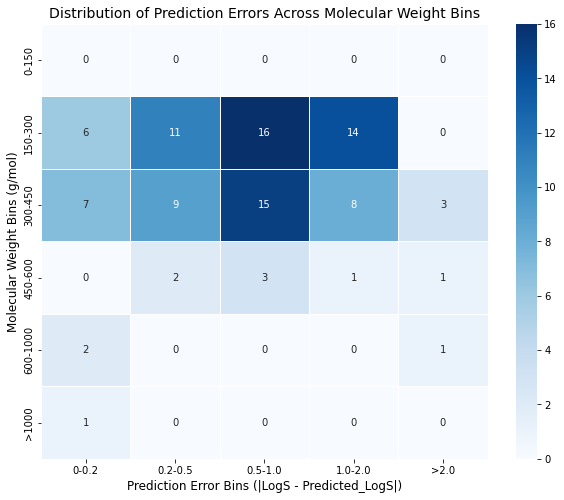

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Assuming you have the dataframe `df` with columns: 'Molecular_Weight', 'Error'

# Define bins for Molecular Weight (g/mol)
mw_bins = [0, 150, 300, 450, 600, 1000, np.inf]
mw_labels = ["0-150", "150-300", "300-450", "450-600", "600-1000", ">1000"]

# Define bins for Prediction Error (|LogS - Predicted_LogS|)
error_bins = [0, 0.2, 0.5, 1.0, 2.0, np.inf]
error_labels = ["0-0.2", "0.2-0.5", "0.5-1.0", "1.0-2.0", ">2.0"]

# Assign bins to the DataFrame
df_set1["MW_Bin"] = pd.cut(df_set1["MW"], bins=mw_bins, labels=mw_labels)
df_set1["Error_Bin"] = pd.cut(df_set1["Error"], bins=error_bins, labels=error_labels)

# Create a pivot table to count the occurrences
heatmap_data = df_set1.groupby(["MW_Bin", "Error_Bin"]).size().unstack().fillna(0)

# Plotting the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, cmap="Blues", fmt="d", linewidths=0.5)

# Adding labels and title
plt.title("Distribution of Prediction Errors Across Molecular Weight Bins", fontsize=14)
plt.xlabel("Prediction Error Bins (|LogS - Predicted_LogS|)", fontsize=12)
plt.ylabel("Molecular Weight Bins (g/mol)", fontsize=12)

# Show the plot
plt.show()



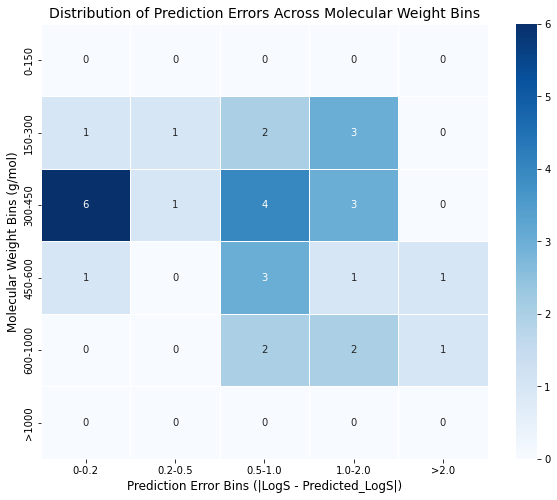

In [109]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np



# Define bins for Molecular Weight (g/mol)
mw_bins = [0, 150, 300, 450, 600, 1000, np.inf]
mw_labels = ["0-150", "150-300", "300-450", "450-600", "600-1000", ">1000"]

# Define bins for Prediction Error (|LogS - Predicted_LogS|)
error_bins = [0, 0.2, 0.5, 1.0, 2.0, np.inf]
error_labels = ["0-0.2", "0.2-0.5", "0.5-1.0", "1.0-2.0", ">2.0"]

# Assign bins to the DataFrame
df_set2["MW_Bin"] = pd.cut(df_set2["MW"], bins=mw_bins, labels=mw_labels)
df_set2["Error_Bin"] = pd.cut(df_set2["Error"], bins=error_bins, labels=error_labels)

# Create a pivot table to count the occurrences
heatmap_data = df_set2.groupby(["MW_Bin", "Error_Bin"]).size().unstack().fillna(0)

# Plotting the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(heatmap_data, annot=True, cmap="Blues", fmt="d", linewidths=0.5)

# Adding labels and title
plt.title("Distribution of Prediction Errors Across Molecular Weight Bins", fontsize=14)
plt.xlabel("Prediction Error Bins (|LogS - Predicted_LogS|)", fontsize=12)
plt.ylabel("Molecular Weight Bins (g/mol)", fontsize=12)

# Show the plot
plt.show()



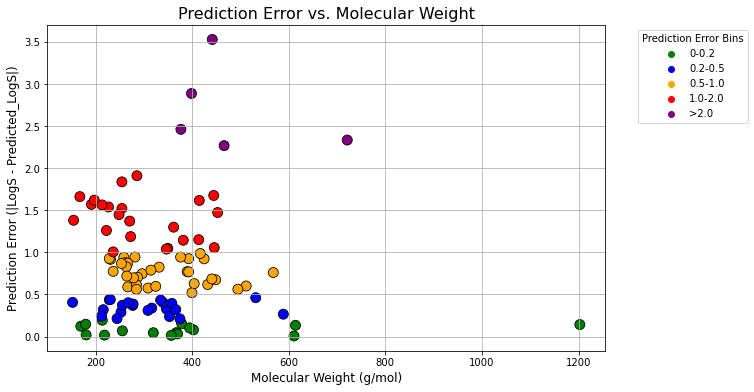

In [108]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np


# Define bins for Molecular Weight (g/mol)
mw_bins = [0, 150, 300, 450, 600, 1000, np.inf]
mw_labels = ["0-150", "150-300", "300-450", "450-600", "600-1000", ">1000"]

# Define bins for Prediction Error (|LogS - Predicted_LogS|)
error_bins = [0, 0.2, 0.5, 1.0, 2.0, np.inf]
error_labels = ["0-0.2", "0.2-0.5", "0.5-1.0", "1.0-2.0", ">2.0"]

# Assign bins to the DataFrame
df_set1["MW_Bin"] = pd.cut(df_set1["MW"], bins=mw_bins, labels=mw_labels)
df_set1["Error_Bin"] = pd.cut(df_set1["Error"], bins=error_bins, labels=error_labels)

# Set a color palette to distinguish error bins
error_palette = {
    "0-0.2": "green",
    "0.2-0.5": "blue",
    "0.5-1.0": "orange",
    "1.0-2.0": "red",
    ">2.0": "purple"
}

# Plotting the scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_set1, x="MW", y="Error", hue="Error_Bin", palette=error_palette, s=100, edgecolor='black', legend="full")

# Customize the plot
plt.title("Prediction Error vs. Molecular Weight", fontsize=16)
plt.xlabel("Molecular Weight (g/mol)", fontsize=12)
plt.ylabel("Prediction Error (|LogS - Predicted_LogS|)", fontsize=12)
plt.legend(title="Prediction Error Bins", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)

# Show the plot
plt.show()


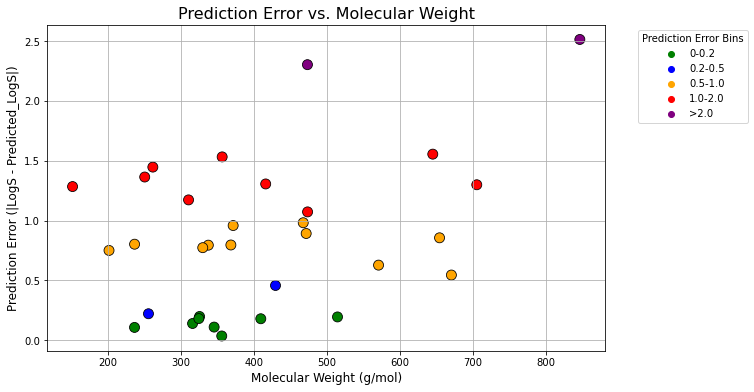

In [106]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np


# Define bins for Molecular Weight (g/mol)
mw_bins = [0, 150, 300, 450, 600, 1000, np.inf]
mw_labels = ["0-150", "150-300", "300-450", "450-600", "600-1000", ">1000"]

# Define bins for Prediction Error (|LogS - Predicted_LogS|)
error_bins = [0, 0.2, 0.5, 1.0, 2.0, np.inf]
error_labels = ["0-0.2", "0.2-0.5", "0.5-1.0", "1.0-2.0", ">2.0"]

# Assign bins to the DataFrame
df_set2["MW_Bin"] = pd.cut(df_set2["MW"], bins=mw_bins, labels=mw_labels)
df_set2["Error_Bin"] = pd.cut(df_set2["Error"], bins=error_bins, labels=error_labels)

# Set a color palette to distinguish error bins
error_palette = {
    "0-0.2": "green",
    "0.2-0.5": "blue",
    "0.5-1.0": "orange",
    "1.0-2.0": "red",
    ">2.0": "purple"
}

# Plotting the scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_set2, x="MW", y="Error", hue="Error_Bin", palette=error_palette, s=100, edgecolor='black', legend="full")

# Customize the plot
plt.title("Prediction Error vs. Molecular Weight", fontsize=16)
plt.xlabel("Molecular Weight (g/mol)", fontsize=12)
plt.ylabel("Prediction Error (|LogS - Predicted_LogS|)", fontsize=12)
plt.legend(title="Prediction Error Bins", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.grid(True)

# Show the plot
plt.show()


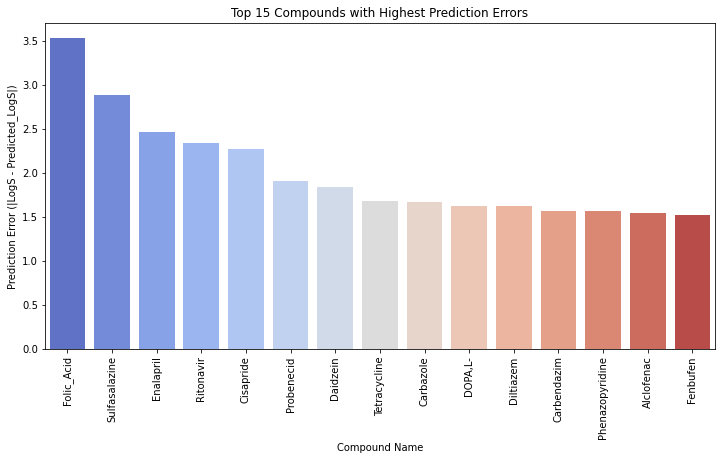

In [77]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute absolute errors
df_set1["Error"] = abs(df_set1["LogS"] - df_set1["Predicted_LogS"])

# Sort by error magnitude (descending)
df_sorted = df_set1.sort_values(by="Error", ascending=False)

# Plot the top 15 compounds with highest errors
plt.figure(figsize=(12,6))
sns.barplot(x=df_sorted["COMPOUND_Name"][:15], y=df_sorted["Error"][:15], palette="coolwarm")
plt.xticks(rotation=90)
plt.xlabel("Compound Name")
plt.ylabel("Prediction Error (|LogS - Predicted_LogS|)")
plt.title("Top 15 Compounds with Highest Prediction Errors")
plt.show()


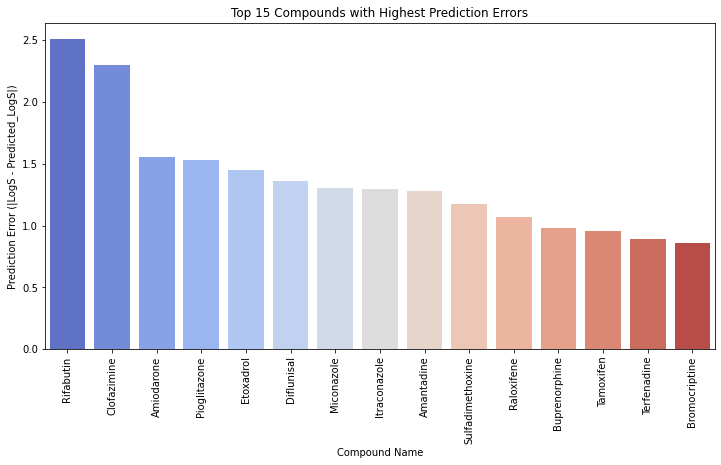

In [105]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute absolute errors
df_set2["Error"] = abs(df_set2["LogS"] - df_set2["Predicted_LogS"])

# Sort by error magnitude (descending)
df_sorted = df_set2.sort_values(by="Error", ascending=False)

# Plot the top 15 compounds with highest errors
plt.figure(figsize=(12,6))
sns.barplot(x=df_sorted["COMPOUND"][:15], y=df_sorted["Error"][:15], palette="coolwarm")
plt.xticks(rotation=90)
plt.xlabel("Compound Name")
plt.ylabel("Prediction Error (|LogS - Predicted_LogS|)")
plt.title("Top 15 Compounds with Highest Prediction Errors")
plt.show()

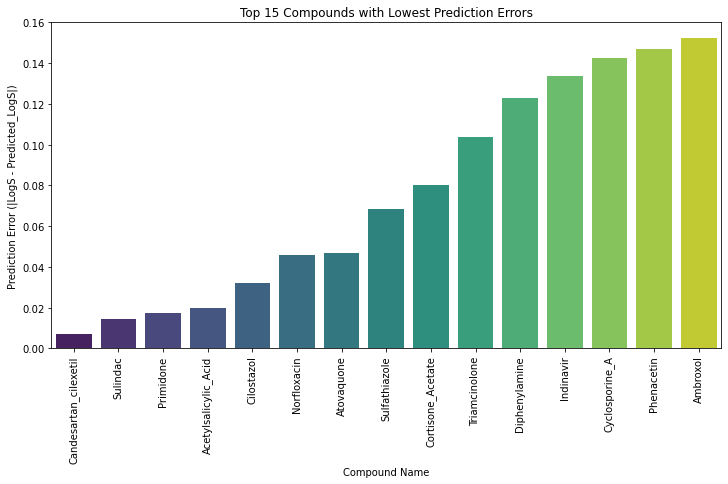

In [80]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute absolute errors
df_set1["Error"] = abs(df_set1["LogS"] - df_set1["Predicted_LogS"])

# Sort by lowest error magnitude
df_sorted_lowest = df_set1.sort_values(by="Error", ascending=True)

# Plot the top 15 compounds with the lowest errors
plt.figure(figsize=(12,6))
sns.barplot(x=df_sorted_lowest["COMPOUND_Name"][:15], y=df_sorted_lowest["Error"][:15], palette="viridis")
plt.xticks(rotation=90)
plt.xlabel("Compound Name")
plt.ylabel("Prediction Error (|LogS - Predicted_LogS|)")
plt.title("Top 15 Compounds with Lowest Prediction Errors")
plt.show()


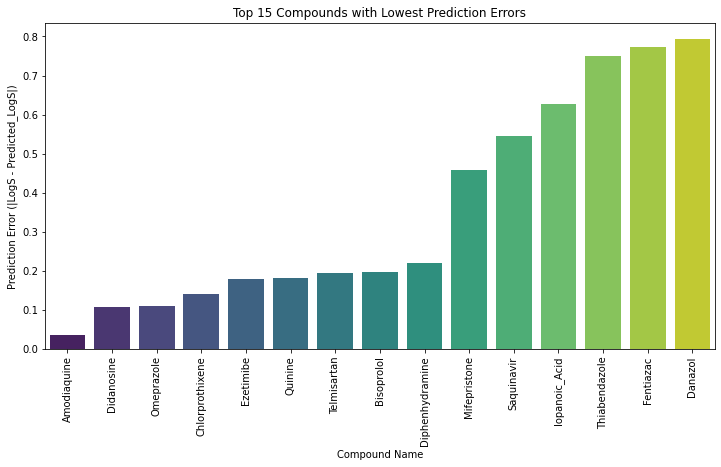

In [103]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute absolute errors
df_set2["Error"] = abs(df_set2["LogS"] - df_set2["Predicted_LogS"])

# Sort by lowest error magnitude
df_sorted_lowest = df_set2.sort_values(by="Error", ascending=True)

# Plot the top 15 compounds with the lowest errors
plt.figure(figsize=(12,6))
sns.barplot(x=df_sorted_lowest["COMPOUND"][:15], y=df_sorted_lowest["Error"][:15], palette="viridis")
plt.xticks(rotation=90)
plt.xlabel("Compound Name")
plt.ylabel("Prediction Error (|LogS - Predicted_LogS|)")
plt.title("Top 15 Compounds with Lowest Prediction Errors")
plt.show()

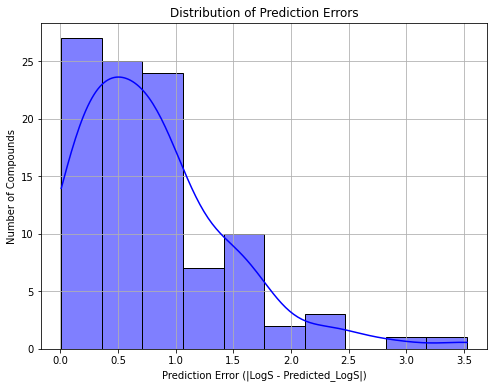

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute absolute errors
df_set1["Error"] = abs(df_set1["LogS"] - df_set1["Predicted_LogS"])

# Plot histogram of error distribution
plt.figure(figsize=(8,6))
sns.histplot(df_set1["Error"], bins=10, kde=True, color="blue")  # 10 bins for better grouping

plt.xlabel("Prediction Error (|LogS - Predicted_LogS|)")
plt.ylabel("Number of Compounds")
plt.title("Distribution of Prediction Errors")
plt.grid(True)
plt.show()


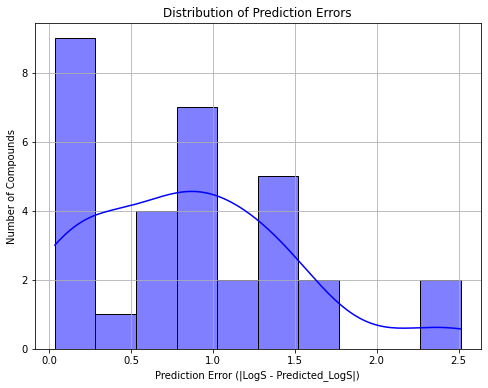

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns

# Compute absolute errors
df_set2["Error"] = abs(df_set2["LogS"] - df_set2["Predicted_LogS"])

# Plot histogram of error distribution
plt.figure(figsize=(8,6))
sns.histplot(df_set2["Error"], bins=10, kde=True, color="blue")  # 10 bins for better grouping

plt.xlabel("Prediction Error (|LogS - Predicted_LogS|)")
plt.ylabel("Number of Compounds")
plt.title("Distribution of Prediction Errors")
plt.grid(True)
plt.show()

In [97]:
df_set1['Sol_g_l']=(10**df_set1.Predicted_LogS)*df_set1.MW
df_set2['Sol_g_l']=(10**df_set2.Predicted_LogS)*df_set2.MW

In [99]:
### saving the predicted csv file to the disk 

df_set1.to_csv("JCIM_set1_prediction.csv", index=False)  ### 100 compounds 
df_set2.to_csv("JCIM_set2_prediction.csv", index=False)  ### 32 compounds 